In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

In [2]:
URL = r"https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Historical_Wildfires.csv"
df = pd.read_csv(URL)
print("Data read into a pandas dataframe!")
df.head()

Data read into a pandas dataframe!


,Region,Date,Estimated_fire_area,Mean_estimated_fire_brightness,Mean_estimated_fire_radiative_power,Mean_confidence,Std_confidence,Var_confidence,Count,Replaced
0,NSW,1/4/2005,8.68000,312.266667,42.400000,78.666667,2.886751,8.333333,3,R
1,NSW,1/5/2005,16.61125,322.475000,62.362500,85.500000,8.088793,65.428571,8,R
2,NSW,1/6/2005,5.52000,325.266667,38.400000,78.333333,3.214550,10.333333,3,R
3,NSW,1/7/2005,6.26400,313.870000,33.800000,92.200000,7.529940,56.700000,5,R
4,NSW,1/8/2005,5.40000,337.383333,122.533333,91.000000,7.937254,63.000000,3,R


In [3]:
df.dtypes

Region                                  object
Date                                    object
Estimated_fire_area                    float64
Mean_estimated_fire_brightness         float64
Mean_estimated_fire_radiative_power    float64
Mean_confidence                        float64
Std_confidence                         float64
Var_confidence                         float64
Count                                    int64
Replaced                                object
dtype: object

In [5]:
df.describe()

,Estimated_fire_area,Mean_estimated_fire_brightness,Mean_estimated_fire_radiative_power,Mean_confidence,Std_confidence,Var_confidence,Count
count,26406.000000,26406.000000,26406.000000,26406.000000,24199.000000,24199.000000,26406.000000
mean,144.297966,319.662078,83.621258,87.574735,7.228302,56.229092,72.059305
std,314.453847,8.862005,67.510022,4.371972,1.995221,25.898935,150.973128
min,1.000000,290.700000,0.000000,76.000000,0.000000,0.000000,1.000000
25%,8.911875,313.933333,44.150391,85.000000,6.687010,44.716106,5.000000
50%,38.434091,319.784412,67.133333,87.771429,7.707025,59.398234,20.000000
75%,146.951278,325.403144,103.123611,90.498403,8.236665,67.842642,74.000000
max,10120.943170,381.950000,2178.600000,100.000000,16.970563,288.000000,3954.000000


In [9]:
import datetime as dt
df['Year'] = pd.to_datetime(df['Date']).dt.year
df['Month'] = pd.to_datetime(df['Date']).dt.month

In [10]:
df.dtypes

Region                                  object
Date                                    object
Estimated_fire_area                    float64
Mean_estimated_fire_brightness         float64
Mean_estimated_fire_radiative_power    float64
Mean_confidence                        float64
Std_confidence                         float64
Var_confidence                         float64
Count                                    int64
Replaced                                object
Year                                     int32
Month                                    int32
dtype: object

In [12]:
avg_fire_area = df.groupby('Year')['Estimated_fire_area'].mean()
avg_fire_area.head()

Year
2005     92.770501
2006    176.289434
2007    153.112464
2008     99.758968
2009    141.624955
Name: Estimated_fire_area, dtype: float64

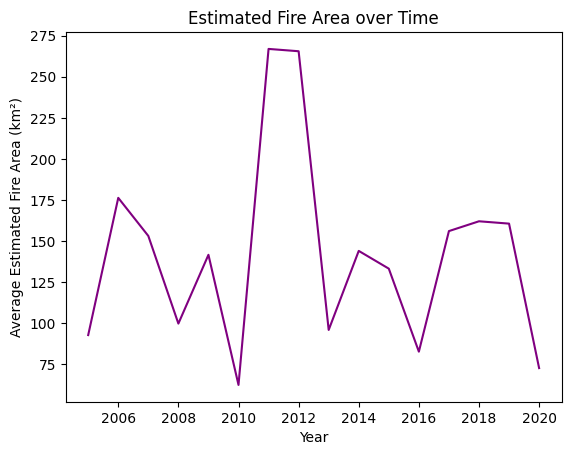

In [20]:
avg_fire_area.plot(x=avg_fire_area.index, y=avg_fire_area.values, color = 'purple')
plt.xlabel('Year')
plt.ylabel('Average Estimated Fire Area (km²)')
plt.title('Estimated Fire Area over Time')
plt.show()

In [29]:
avg_fire_aream = df.groupby(['Year','Month'])['Estimated_fire_area'].mean()
avg_fire_aream.head()

Year  Month
2005  1         70.619908
      2        101.018747
      3         40.901576
      4         69.305388
      5         93.834520
Name: Estimated_fire_area, dtype: float64

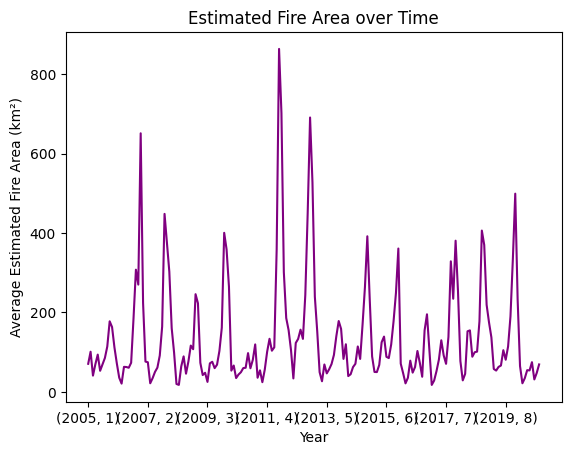

In [30]:
avg_fire_aream.plot(x=avg_fire_aream.index, y=avg_fire_aream.values, color = 'purple')
plt.xlabel('Year')
plt.ylabel('Average Estimated Fire Area (km²)')
plt.title('Estimated Fire Area over Time')
plt.show()

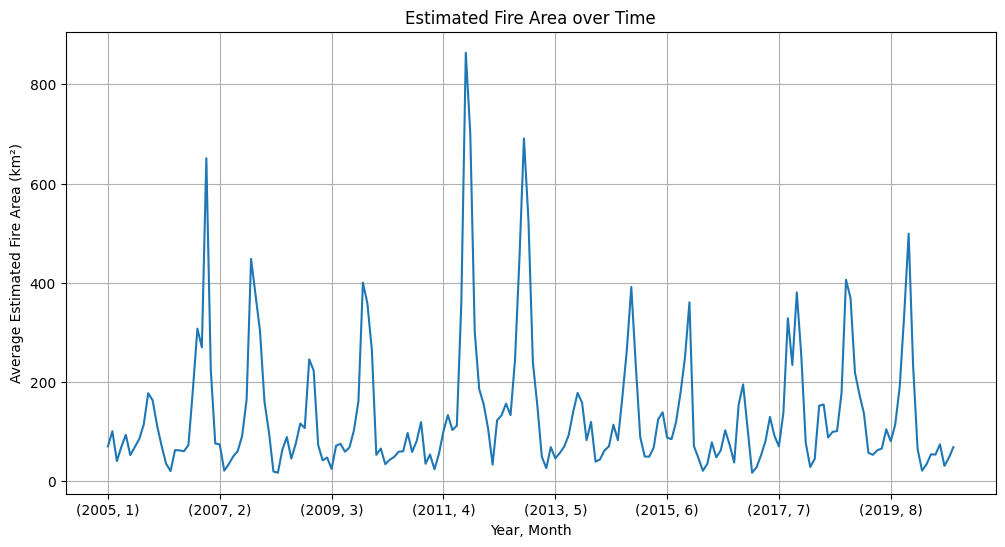

In [35]:
df_new = df.groupby(['Year','Month'])['Estimated_fire_area'].mean()
# Plotting the data
df_new.plot(x=df_new.index, y=df_new.values, figsize = (12,6))
plt.xlabel('Year, Month')
plt.ylabel('Average Estimated Fire Area (km²)')
plt.title('Estimated Fire Area over Time')
plt.grid(True)
plt.show()

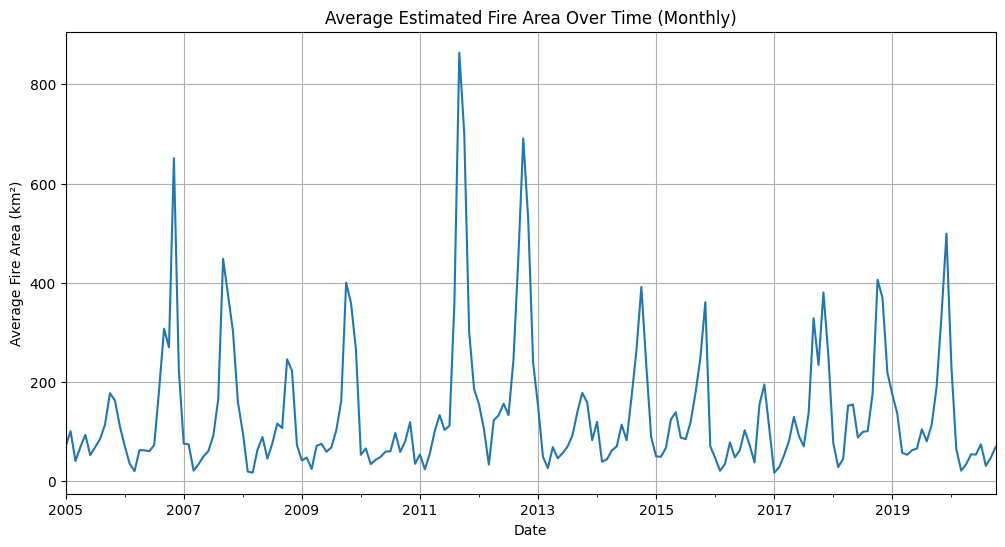

In [31]:
# Group by Year-Month instead of just Year
df['YearMonth'] = pd.to_datetime(df['Date']).dt.to_period('M')

avg_fire_area_monthly = df.groupby('YearMonth')['Estimated_fire_area'].mean()

# Plot
plt.figure(figsize=(12,6))
avg_fire_area_monthly.plot(kind='line')

plt.title("Average Estimated Fire Area Over Time (Monthly)")
plt.xlabel("Date")
plt.ylabel("Average Fire Area (km²)")
plt.grid(True)
plt.show()


In [32]:
df['YearMonth']

0        2005-01
1        2005-01
2        2005-01
3        2005-01
4        2005-01
          ...   
26401    2020-10
26402    2020-10
26403    2020-10
26404    2020-10
26405    2020-10
Name: YearMonth, Length: 26406, dtype: period[M]

In [36]:
df['Region'].unique()

array(['NSW', 'NT', 'QL', 'SA', 'TA', 'VI', 'WA'], dtype=object)

In [37]:
df_regions = df.groupby('Region')['Mean_estimated_fire_brightness'].mean()
df_regions.head()

Region
NSW    315.526218
NT     322.898453
QL     318.364434
SA     321.497609
TA     313.368483
Name: Mean_estimated_fire_brightness, dtype: float64

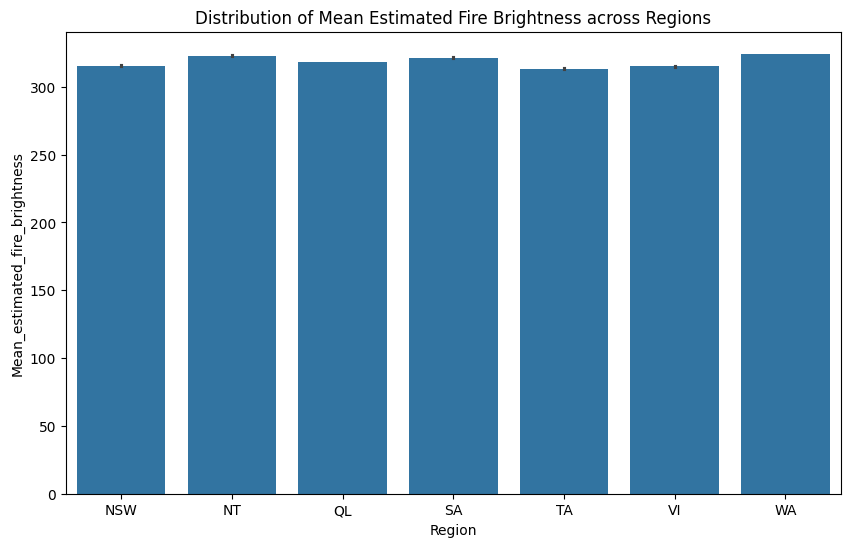

In [40]:
plt.figure(figsize = (10,6))
sns.barplot(x = 'Region', y ='Mean_estimated_fire_brightness', data = df )
plt.title('Distribution of Mean Estimated Fire Brightness across Regions')
plt.show()

<Axes: xlabel='Region'>

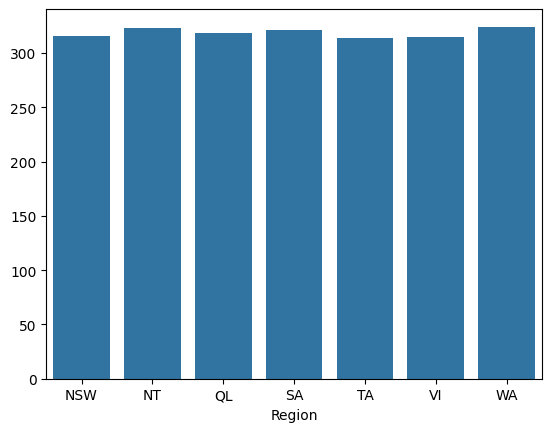

In [43]:
sns.barplot(x = df_regions.index, y = df_regions.values)

In [44]:
df.head(10)

,Region,Date,Estimated_fire_area,Mean_estimated_fire_brightness,Mean_estimated_fire_radiative_power,Mean_confidence,Std_confidence,Var_confidence,Count,Replaced,Year,Month,YearMonth
0,NSW,1/4/2005,8.680000,312.266667,42.400000,78.666667,2.886751,8.333333,3,R,2005,1,2005-01
1,NSW,1/5/2005,16.611250,322.475000,62.362500,85.500000,8.088793,65.428571,8,R,2005,1,2005-01
2,NSW,1/6/2005,5.520000,325.266667,38.400000,78.333333,3.214550,10.333333,3,R,2005,1,2005-01
3,NSW,1/7/2005,6.264000,313.870000,33.800000,92.200000,7.529940,56.700000,5,R,2005,1,2005-01
4,NSW,1/8/2005,5.400000,337.383333,122.533333,91.000000,7.937254,63.000000,3,R,2005,1,2005-01
5,NSW,1/9/2005,13.721429,314.757143,64.542857,83.142857,6.175990,38.142857,7,R,2005,1,2005-01
6,NSW,1/10/2005,16.625455,324.800000,58.554545,91.454545,6.088738,37.072727,11,R,2005,1,2005-01
7,NSW,1/11/2005,32.784375,318.446875,66.812500,91.000000,10.132456,102.666667,16,R,2005,1,2005-01
8,NSW,1/12/2005,16.486154,323.238462,40.607692,87.769231,8.623165,74.358974,13,R,2005,1,2005-01
9,NSW,1/13/2005,42.640000,325.376667,87.573333,86.666667,7.499206,56.238095,15,R,2005,1,2005-01


In [53]:
df_reg = df.groupby('Region')['Count'].sum()
df_reg

Region
NSW    117412
NT     649430
QL     420882
SA      35160
TA      11473
VI      52473
WA     615968
Name: Count, dtype: int64

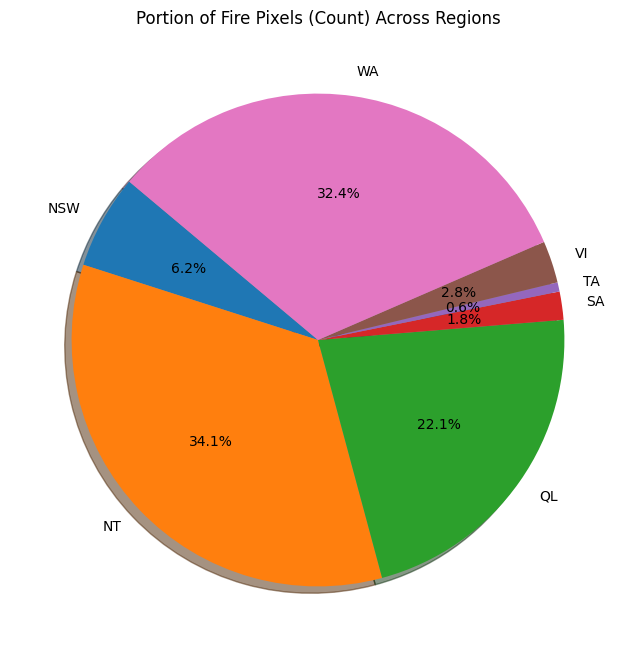

In [56]:
df_reg.plot(kind='pie', figsize=(8,8), autopct='%1.1f%%', startangle=140, ylabel='', shadow = True)
plt.title('Portion of Fire Pixels (Count) Across Regions')
plt.show()

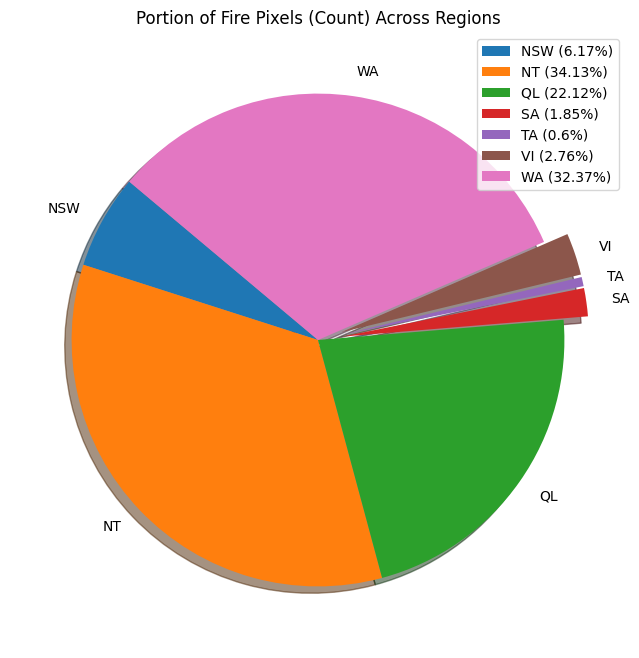

In [58]:
region_counts = df.groupby('Region')['Count'].sum()
explode = [0.1 if val < 60000 else 0 for val in region_counts]
region_counts.plot(
    kind='pie',
    figsize=(8,8),
    startangle=140,
    explode=explode,
    shadow=True,
    ylabel=''
)

plt.title('Portion of Fire Pixels (Count) Across Regions')
plt.legend(
    [f"{i} ({round(k/region_counts.sum()*100,2)}%)" for i,k in zip(region_counts.index, region_counts)],
    loc="best"
)
plt.show()

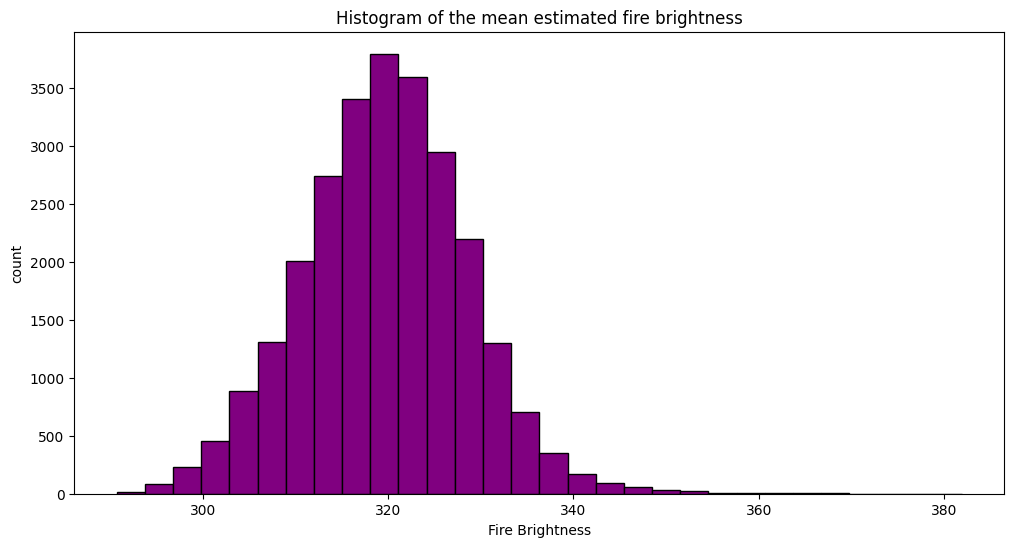

In [61]:
plt.figure(figsize = (12,6))
plt.hist(df['Mean_estimated_fire_brightness'], bins = 30, color = 'purple' , edgecolor = 'black')
plt.xlabel("Fire Brightness")
plt.ylabel("count")
plt.title("Histogram of the mean estimated fire brightness")
plt.show()

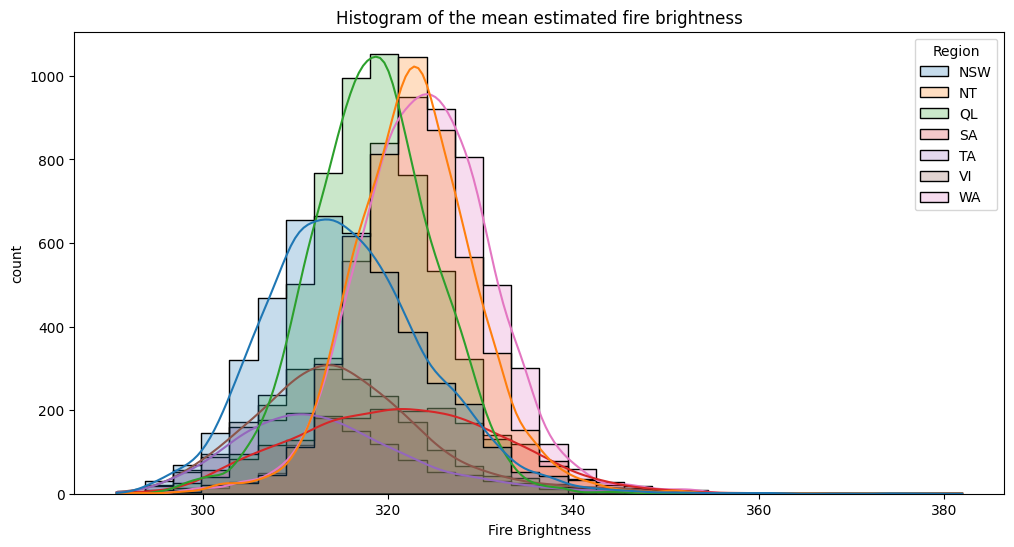

In [77]:
plt.figure(figsize = (12,6))
sns.histplot(data = df, x = 'Mean_estimated_fire_brightness', hue ='Region', bins = 30, element = 'step', color = 'purple' , edgecolor = 'black', kde = True)
plt.xlabel("Fire Brightness")
plt.ylabel("count")
plt.title("Histogram of the mean estimated fire brightness")
plt.show()

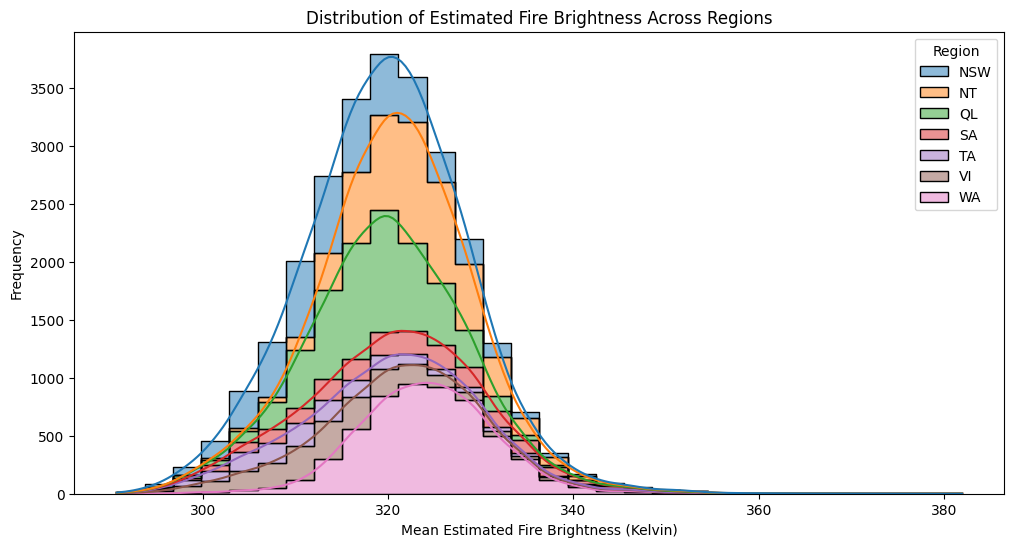

In [78]:
plt.figure(figsize=(12,6))
sns.histplot(
    data=df,
    x='Mean_estimated_fire_brightness',
    hue='Region',
    bins=30,
    kde=True,        # adds smooth curve for better visualization
    element="step",
    multiple = 'stack'# outline style instead of filled bars
)

plt.title('Distribution of Estimated Fire Brightness Across Regions')
plt.xlabel('Mean Estimated Fire Brightness (Kelvin)')
plt.ylabel('Frequency')
plt.show()

In [79]:
df.head()

,Region,Date,Estimated_fire_area,Mean_estimated_fire_brightness,Mean_estimated_fire_radiative_power,Mean_confidence,Std_confidence,Var_confidence,Count,Replaced,Year,Month,YearMonth
0,NSW,1/4/2005,8.68000,312.266667,42.400000,78.666667,2.886751,8.333333,3,R,2005,1,2005-01
1,NSW,1/5/2005,16.61125,322.475000,62.362500,85.500000,8.088793,65.428571,8,R,2005,1,2005-01
2,NSW,1/6/2005,5.52000,325.266667,38.400000,78.333333,3.214550,10.333333,3,R,2005,1,2005-01
3,NSW,1/7/2005,6.26400,313.870000,33.800000,92.200000,7.529940,56.700000,5,R,2005,1,2005-01
4,NSW,1/8/2005,5.40000,337.383333,122.533333,91.000000,7.937254,63.000000,3,R,2005,1,2005-01


In [82]:
df[['Mean_estimated_fire_radiative_power','Mean_confidence']].corr()

,Mean_estimated_fire_radiative_power,Mean_confidence
Mean_estimated_fire_radiative_power,1.000000,0.452322
Mean_confidence,0.452322,1.000000


Text(0.5, 1.0, 'correlation between mean estimated fire radiative power and mean confidence level')

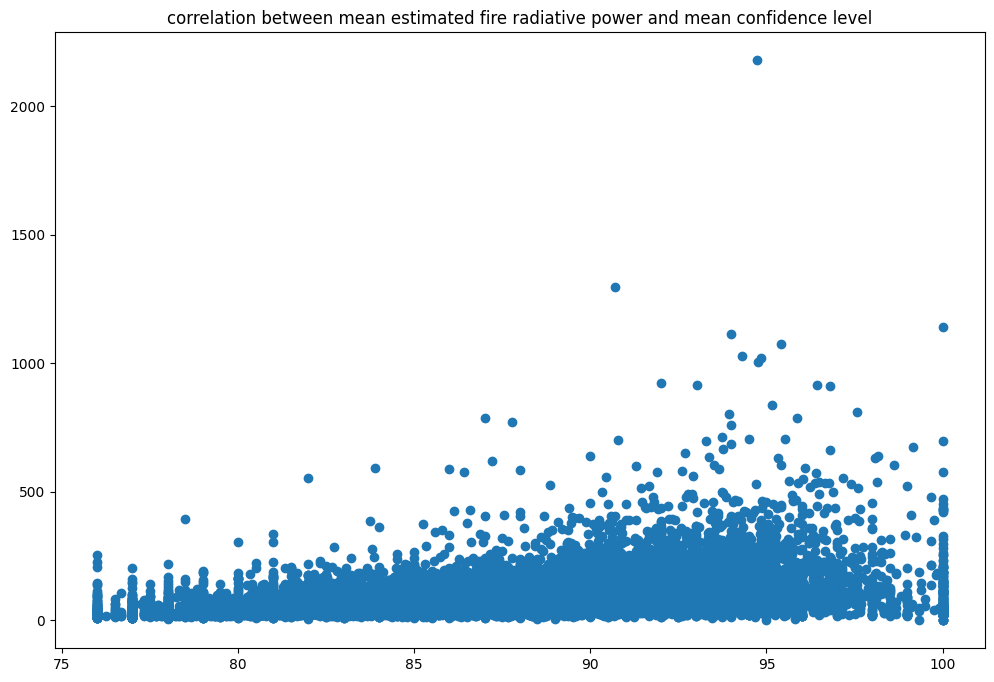

In [85]:
plt.figure(figsize = (12,8))
plt.scatter(x = 'Mean_confidence', y = 'Mean_estimated_fire_radiative_power', data = df)
plt.title("correlation between mean estimated fire radiative power and mean confidence level")

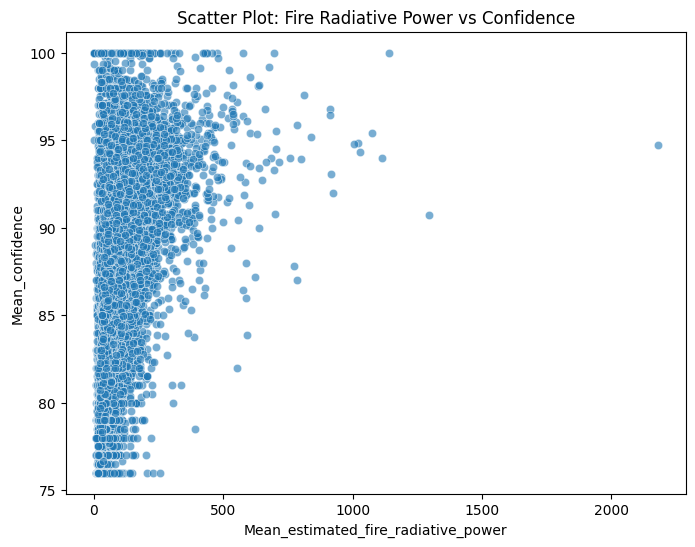

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df, 
    x="Mean_estimated_fire_radiative_power", 
    y="Mean_confidence",
    alpha=0.6,    # transparency so overlapping points are visible
    edgecolor="w"
)
plt.title("Scatter Plot: Fire Radiative Power vs Confidence")
plt.show()


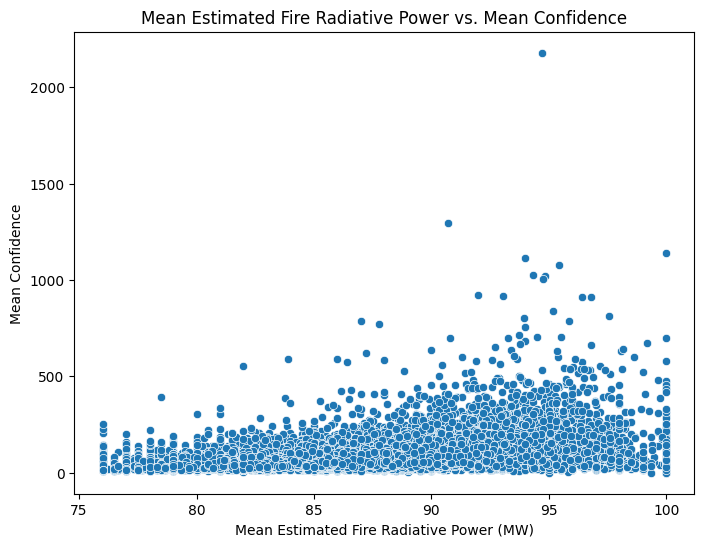

In [88]:
plt.figure(figsize=(8, 6))
# Using sns.scatterplot to create the scatter plot
# Specifying the DataFrame (data=df) and the columns for the x-axis (x='Mean_confidence') and y-axis            (y='Mean_estimated_fire_radiative_power')
sns.scatterplot(data=df, x='Mean_confidence', y='Mean_estimated_fire_radiative_power')
plt.xlabel('Mean Estimated Fire Radiative Power (MW)')
plt.ylabel('Mean Confidence')
plt.title('Mean Estimated Fire Radiative Power vs. Mean Confidence')
plt.show()

In [92]:
import pandas as pd
import folium

# Create DataFrame
region_data = {
    'region': ['NSW','QL','SA','TA','VI','WA','NT'], 
    'Lat': [-31.8759835,-22.1646782,-30.5343665,-42.035067,-36.5986096,-25.2303005,-19.491411], 
    'Lon': [147.2869493,144.5844903,135.6301212,146.6366887,144.6780052,121.0187246,132.550964]
}
reg = pd.DataFrame(region_data)

# Base map
m = folium.Map(location=[-25, 135], zoom_start=4)

# Add markers using zip
for region, lat, lon in zip(reg['region'], reg['Lat'], reg['Lon']):
    folium.Marker(
        location=[lat, lon],
        popup=region,
        tooltip=region,
        icon=folium.Icon(color="red", icon="info-sign")
    ).add_to(m)

# Show map
m


In [91]:
reg.head()

,region,Lat,Lon
0,NSW,-31.875984,147.286949
1,QL,-22.164678,144.584490
2,SA,-30.534367,135.630121
3,TA,-42.035067,146.636689
4,VI,-36.598610,144.678005
